In [4]:
import sys
sys.path.append('../data')
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('../data/deeplearning.mplstyle')
np.set_printoptions(precision=2)

In [5]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
Y_train = np.array([460, 232, 178])

In [6]:
print(f"X shape : {X_train.shape} , Type : {type(X_train)}")
print(X_train)
print(f"Y shape : {Y_train.shape} , Type : {type(X_train)}")
print(Y_train)

X shape : (3, 4) , Type : <class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
Y shape : (3,) , Type : <class 'numpy.ndarray'>
[460 232 178]


In [7]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"W_init shape {w_init.shape} , b_init : {type(b_init)}")

W_init shape (4,) , b_init : <class 'float'>


In [8]:
def predict_singleloop(x,w,b):
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]
        p = p + p_i
    p = p + b

    return p


In [9]:
x_vec = X_train[0, :]
print(x_vec)
tic = time.time()
f_wb = predict_singleloop(x_vec,w_init,b_init)
toc = time.time()
print(f"Prediction : {f_wb}")
print(f"Preduction Time : {1000 * (toc - tic):.4e} ms")

[2104    5    1   45]
Prediction : 459.9999976194083
Preduction Time : 4.1962e-02 ms


In [10]:
def predict(x,w,b):
    p = np.dot(x,w) + b

    return p

In [11]:
x_vec = X_train[0, :]
print(x_vec)
tic = time.time()
f_wb = predict(x_vec,w_init,b_init)
toc = time.time()
print(f"Prediction : {f_wb}")
print(f"Preduction Time : {1000 * (toc - tic):.4e} ms")

[2104    5    1   45]
Prediction : 459.99999761940825
Preduction Time : 6.2943e-02 ms


In [12]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        f_wd_i = np.dot(X[i],w) + b
        cost = cost + (f_wd_i - y[i]) ** 2
    cost = cost / (2 * m)
    return cost

In [13]:
cost = compute_cost(X_train,Y_train, w_init,b_init)
print(f"cost at optimat w : {cost}")

cost at optimat w : 1.5578904880036537e-12


In [14]:
def compute_gradient(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        err = (np.dot(X[i],w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db + err
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw , dj_db

In [15]:
tmp_dj_dw , tmp_dj_db = compute_gradient(X_train,Y_train,w_init,b_init)
print(f"dj_dw With initial Weights and bias : {tmp_dj_dw}")
print(f"dj_db With initial Weights and bias : {tmp_dj_db}")

dj_dw With initial Weights and bias : [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]
dj_db With initial Weights and bias : -1.673925169143331e-06


In [16]:
def gradient_descent(X, y,w_init,b_init,cost_function,Gradient_function,alpha,num_iters):
    J_hist = []
    w = copy.deepcopy(w_init)
    b = b_init

    for i in range(num_iters):
        dj_dw , dj_db = Gradient_function(X,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i <  100000:
            J_hist.append(cost_function(X,y,w,b))
        if i%math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4d} : Cost {J_hist[-1]:8.2f} ")

    return w,b,J_hist

In [17]:
int_w = np.zeros_like(w_init)
int_b = 0.

iteration = 1500
alpha = 5.0e-7

W_final, B_final,J_hist = gradient_descent(X_train,Y_train,int_w,int_b,compute_cost,compute_gradient,alpha,iteration)

print(f"w,b found by the gradient Descent: {W_final} ,{B_final:0.2f}")
m,_ = X_train.shape
for i in range(m):
    print(f"Prediction : {np.dot(X_train[i],W_final)+ B_final:0.2f},target Values : {Y_train[i]}")

Iteration    0 : Cost  2529.46 
Iteration  150 : Cost   695.45 
Iteration  300 : Cost   693.86 
Iteration  450 : Cost   692.29 
Iteration  600 : Cost   690.73 
Iteration  750 : Cost   689.20 
Iteration  900 : Cost   687.69 
Iteration 1050 : Cost   686.20 
Iteration 1200 : Cost   684.73 
Iteration 1350 : Cost   683.27 
w,b found by the gradient Descent: [ 0.2   0.01 -0.02 -0.1 ] ,-0.00
Prediction : 426.47,target Values : 460
Prediction : 286.02,target Values : 232
Prediction : 171.00,target Values : 178


Text(0.5, 0, 'Iteration Step')

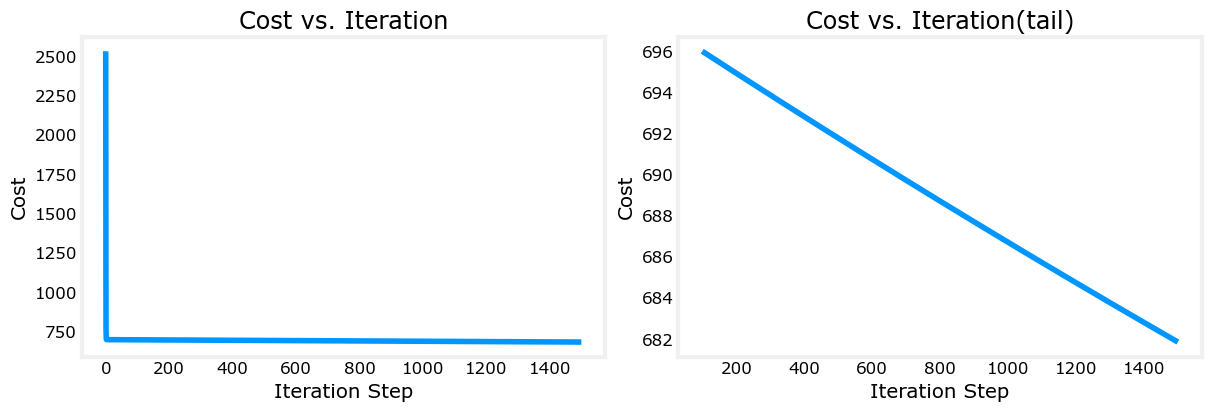

In [18]:
fig,(ax1,ax2) = plt.subplots(1,2, constrained_layout = True , figsize = (12,4) )
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. Iteration")
ax2.set_title("Cost vs. Iteration(tail)")
ax1.set_ylabel('Cost')
ax2.set_ylabel('Cost')
ax1.set_xlabel('Iteration Step')
ax2.set_xlabel('Iteration Step')
